# 1. Cai dat moi truong

In [1]:
%%capture
import os
import torch

TORCH = torch.__version__
os.environ['PYTHONWARNINGS'] = "ignore"
!python -m pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}.html
!python -m pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}.html
!python -m pip install git+https://github.com/pyg-team/pytorch_geometric.git

# 2. Dataset

In [2]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.
print(data)

c:\Users\pc\miniconda3\envs\nt114-kienlt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [5]:
from torch_geometric.nn import GATConv
import torch.nn.functional as F

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATConv(dataset.num_features, hidden_channels,heads)
        self.conv2 = GATConv(heads*hidden_channels, dataset.num_classes,heads)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GAT(hidden_channels=8, heads=8)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()
      out = model(data.x, data.edge_index)
      loss = criterion(out[data.train_mask], data.y[data.train_mask])
      loss.backward()
      optimizer.step()
      return loss

def test(mask):
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)
      correct = pred[mask] == data.y[mask]
      acc = int(correct.sum()) / int(mask.sum())
      return acc

val_acc_all = []
test_acc_all = []

for epoch in range(1, 101):
    loss = train()
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)
    val_acc_all.append(val_acc)
    test_acc_all.append(test_acc)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}')

# .. .. .. ..
# .. .. .. ..
# Epoch: 098, Loss: 1.1283, Val: 0.7960, Test: 0.8030

# Epoch: 099, Loss: 1.1352, Val: 0.7940, Test: 0.8050

# Epoch: 100, Loss: 1.1053, Val: 0.7960, Test: 0.8040

GAT(
  (conv1): GATConv(1433, 8, heads=8)
  (conv2): GATConv(64, 7, heads=8)
)
Epoch: 001, Loss: 4.0241, Val: 0.3360, Test: 0.3540
Epoch: 002, Loss: 3.9902, Val: 0.4560, Test: 0.4840
Epoch: 003, Loss: 3.9517, Val: 0.5040, Test: 0.5440
Epoch: 004, Loss: 3.9093, Val: 0.5420, Test: 0.5850
Epoch: 005, Loss: 3.8561, Val: 0.5440, Test: 0.5920
Epoch: 006, Loss: 3.7976, Val: 0.5560, Test: 0.5940
Epoch: 007, Loss: 3.7441, Val: 0.5620, Test: 0.5990
Epoch: 008, Loss: 3.6630, Val: 0.5660, Test: 0.6000
Epoch: 009, Loss: 3.5806, Val: 0.5700, Test: 0.5920
Epoch: 010, Loss: 3.4879, Val: 0.5740, Test: 0.5910
Epoch: 011, Loss: 3.4109, Val: 0.5780, Test: 0.5880
Epoch: 012, Loss: 3.3064, Val: 0.5780, Test: 0.5850
Epoch: 013, Loss: 3.2024, Val: 0.5780, Test: 0.5860
Epoch: 014, Loss: 3.0787, Val: 0.5820, Test: 0.5860
Epoch: 015, Loss: 2.9788, Val: 0.5800, Test: 0.5880
Epoch: 016, Loss: 2.8652, Val: 0.5740, Test: 0.5860
Epoch: 017, Loss: 2.7460, Val: 0.5680, Test: 0.5840
Epoch: 018, Loss: 2.6412, Val: 0.5680

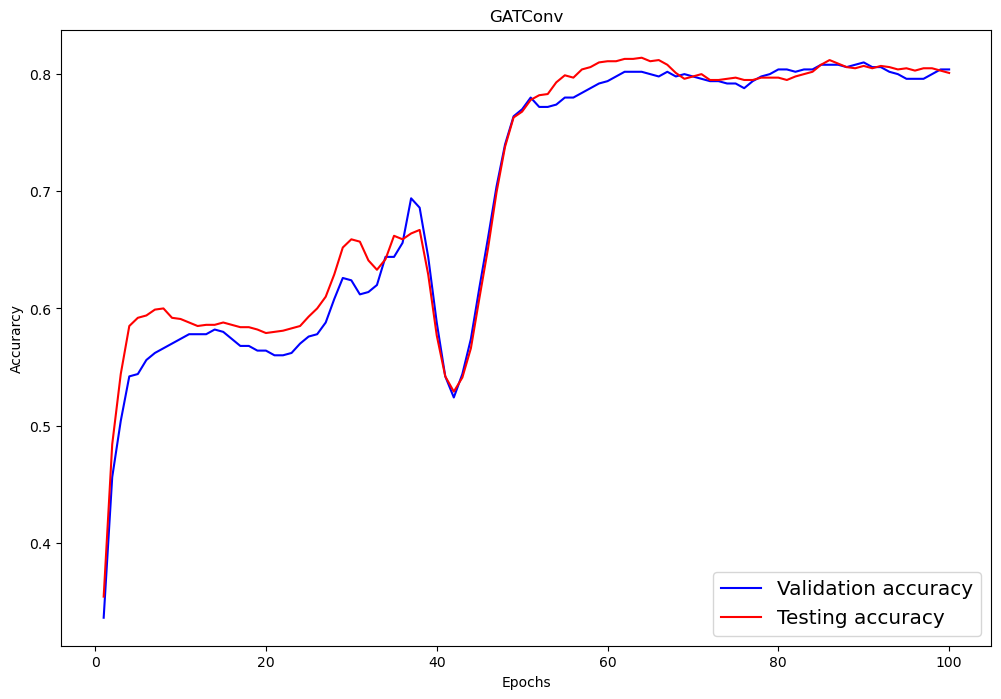

In [8]:
import numpy as np

plt.figure(figsize=(12,8))
plt.plot(np.arange(1, len(val_acc_all) + 1), val_acc_all, label='Validation accuracy', c='blue')
plt.plot(np.arange(1, len(test_acc_all) + 1), test_acc_all, label='Testing accuracy', c='red')
plt.xlabel('Epochs')
plt.ylabel('Accurarcy')
plt.title('GATConv')
plt.legend(loc='lower right', fontsize='x-large')
plt.savefig('gat_loss.png')
plt.show()

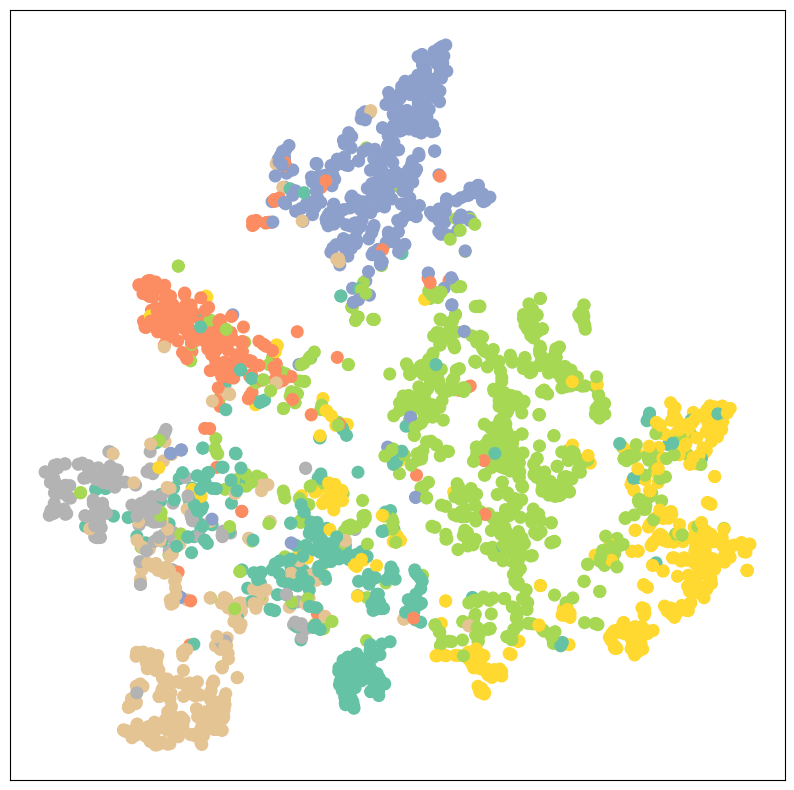

In [9]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)